In [108]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


In [109]:
df = pd.read_csv('d:/ML/ad_rec.csv')

In [110]:
df.shape

(1000, 10)

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  987 non-null    float64
 1   Age                       1000 non-null   int64  
 2   Area Income               987 non-null    float64
 3   Daily Internet Usage      989 non-null    float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      999 non-null    object 
 6   Male                      997 non-null    float64
 7   Country                   991 non-null    object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 78.3+ KB


In [112]:
df.describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,987.000000,1000.000000,987.000000,989.000000,997.000000,1000.00000
mean,64.929524,36.009000,54980.667234,179.863620,0.480441,0.50000
std,15.844699,8.785562,13439.998510,43.870142,0.499868,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000
25%,51.270000,29.000000,46947.570000,138.710000,0.000000,0.00000
50%,68.110000,35.000000,57009.760000,182.650000,0.000000,0.50000
75%,78.460000,42.000000,65479.350000,218.790000,1.000000,1.00000
max,91.430000,61.000000,79484.800000,267.010000,1.000000,1.00000


In [113]:
df['Ad Topic Line']

0         Cloned 5thgeneration orchestration
1         Monitored national standardization
2           Organic bottom-line service-desk
3      Triple-buffered reciprocal time-frame
4              Robust logistical utilization
                       ...                  
995            Fundamental modular algorithm
996          Grass-roots cohesive monitoring
997             Expanded intangible solution
998     Proactive bandwidth-monitored policy
999          Virtual 5thgeneration emulation
Name: Ad Topic Line, Length: 1000, dtype: object

In [114]:
df['City']

0         Wrightburgh
1           West Jodi
2            Davidton
3      West Terrifurt
4        South Manuel
            ...      
995         Duffystad
996       New Darlene
997     South Jessica
998       West Steven
999       Ronniemouth
Name: City, Length: 1000, dtype: object

In [115]:
df['Male']

0      0.0
1      1.0
2      0.0
3      1.0
4      0.0
      ... 
995    1.0
996    1.0
997    1.0
998    0.0
999    0.0
Name: Male, Length: 1000, dtype: float64

In [116]:
df['Country']

0                     Tunisia
1                       Nauru
2                  San Marino
3                       Italy
4                     Iceland
                ...          
995                   Lebanon
996    Bosnia and Herzegovina
997                  Mongolia
998                 Guatemala
999                    Brazil
Name: Country, Length: 1000, dtype: object

In [117]:
df['Timestamp']

0       3/27/2016 0:53
1        4/4/2016 1:39
2      3/13/2016 20:35
3       1/10/2016 2:31
4        6/3/2016 3:36
            ...       
995    2/11/2016 21:49
996     4/22/2016 2:07
997     2/1/2016 17:24
998     3/24/2016 2:35
999     6/3/2016 21:43
Name: Timestamp, Length: 1000, dtype: object

In [118]:
df['Clicked on Ad']

0      0
1      0
2      0
3      0
4      0
      ..
995    1
996    1
997    1
998    0
999    1
Name: Clicked on Ad, Length: 1000, dtype: int64

In [119]:
df.isna().sum()

Daily Time Spent on Site    13
Age                          0
Area Income                 13
Daily Internet Usage        11
Ad Topic Line                0
City                         1
Male                         3
Country                      9
Timestamp                    0
Clicked on Ad                0
dtype: int64

In [120]:
df.dropna(inplace=True)
df = df.copy()

In [121]:
df.duplicated().sum()

np.int64(0)

In [122]:
df[df.duplicated()==True]

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad


In [123]:
df = df.drop_duplicates()

In [124]:
df.shape

(953, 10)

In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 953 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  953 non-null    float64
 1   Age                       953 non-null    int64  
 2   Area Income               953 non-null    float64
 3   Daily Internet Usage      953 non-null    float64
 4   Ad Topic Line             953 non-null    object 
 5   City                      953 non-null    object 
 6   Male                      953 non-null    float64
 7   Country                   953 non-null    object 
 8   Timestamp                 953 non-null    object 
 9   Clicked on Ad             953 non-null    int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 81.9+ KB


In [126]:
df.columns.tolist()

['Daily Time Spent on Site',
 'Age',
 'Area Income',
 'Daily Internet Usage',
 'Ad Topic Line',
 'City',
 'Male',
 'Country',
 'Timestamp',
 'Clicked on Ad']

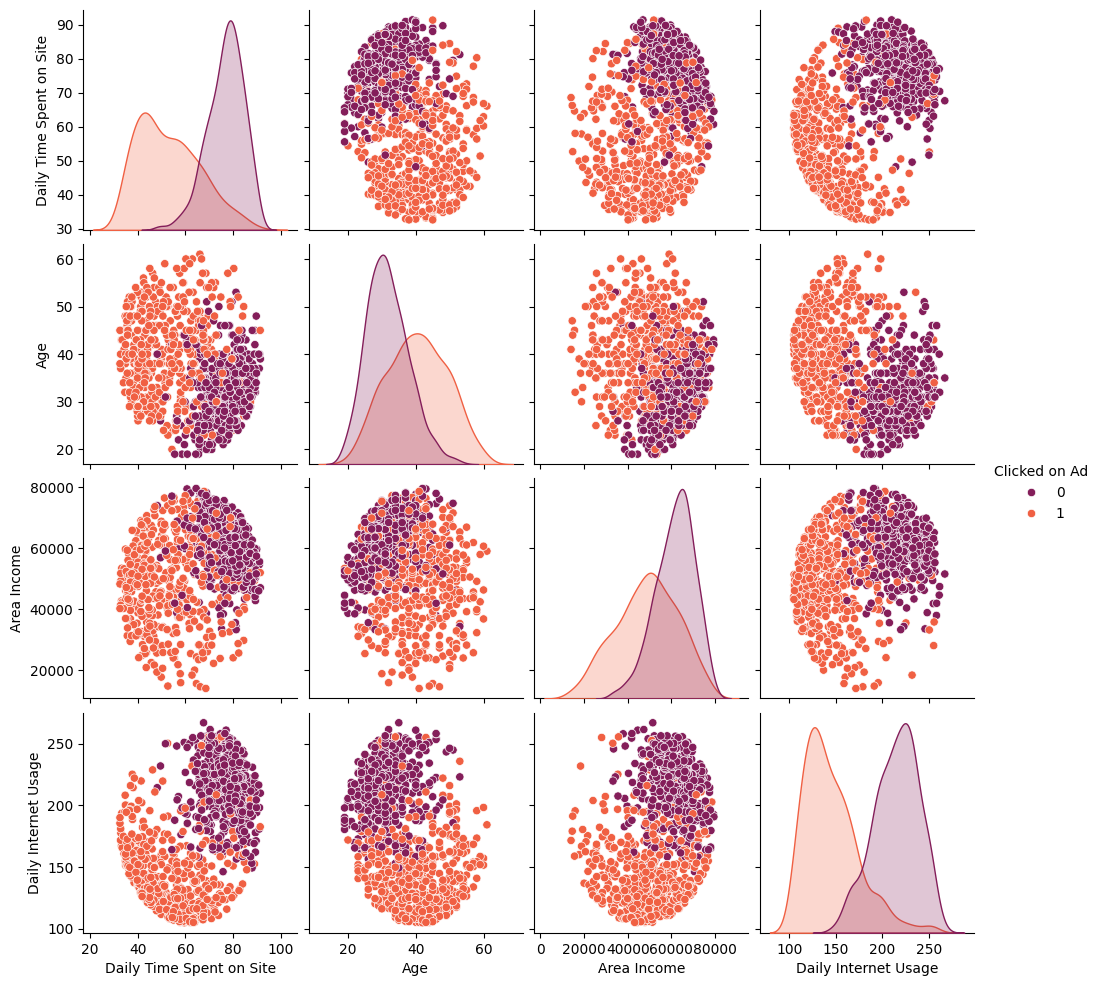

In [127]:
sns.pairplot(df,
             vars=['Daily Time Spent on Site',
                   'Age',
                   'Area Income',
                   'Daily Internet Usage'],
             hue='Clicked on Ad',
             diag_kind='kde',
             palette='rocket')

<Axes: xlabel='Age', ylabel='Count'>

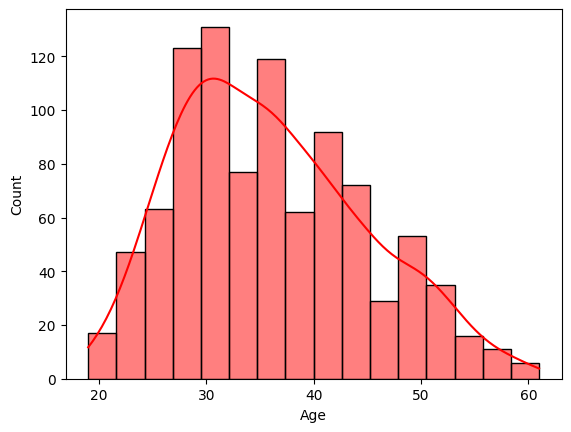

In [128]:
sns.histplot(df['Age'], kde=True, color='r')

<Axes: xlabel='Age', ylabel='Daily Time Spent on Site'>

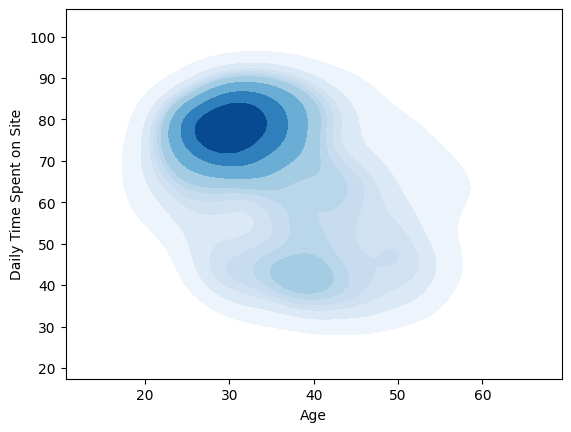

In [130]:
sns.kdeplot(
    x=df['Age'],
    y=df['Daily Time Spent on Site'],
    cmap="Blues",
    fill=True,
    thresh=0.05
)



<Axes: xlabel='Age', ylabel='count'>

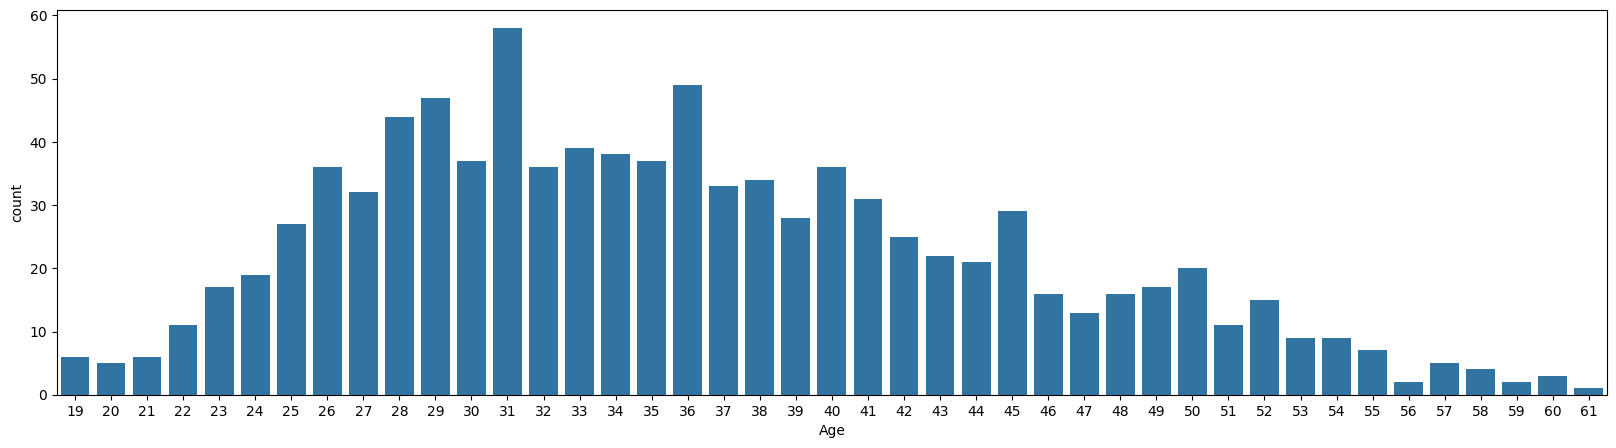

In [131]:
fig = plt.figure(figsize = (20, 5))
sns.countplot(x ='Age', data = df)

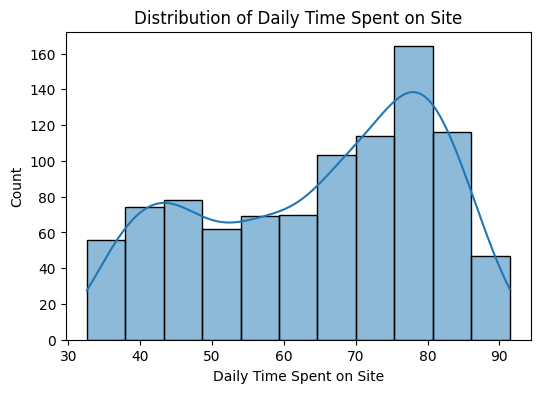

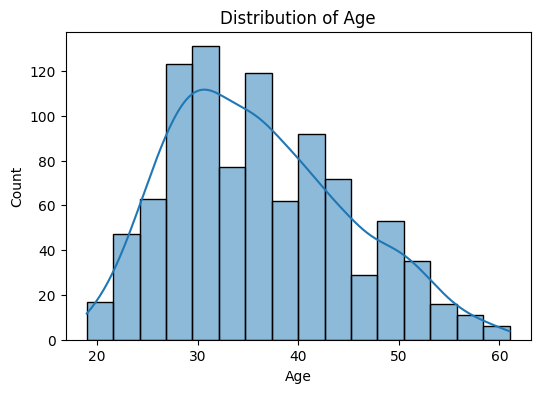

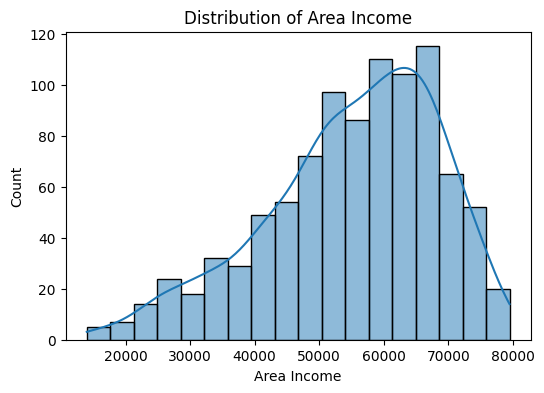

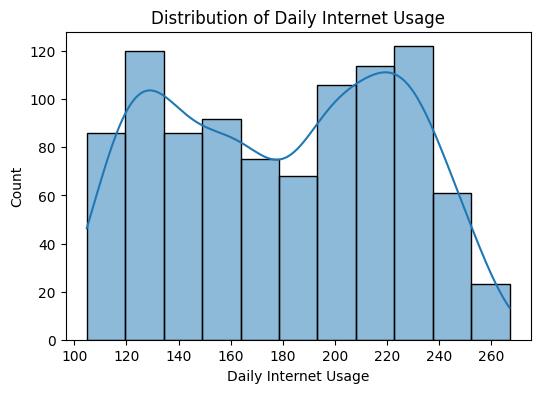

In [132]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

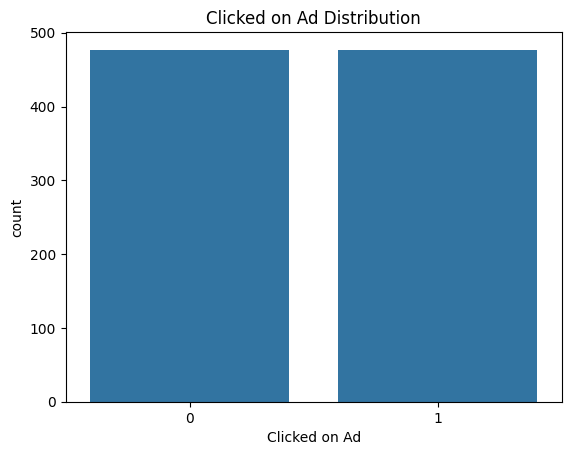

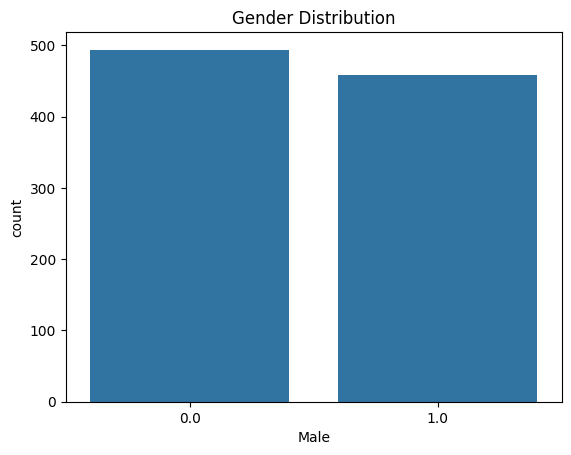

In [133]:
sns.countplot(x='Clicked on Ad', data=df)
plt.title('Clicked on Ad Distribution')
plt.show()

sns.countplot(x='Male', data=df)
plt.title('Gender Distribution')
plt.show()

<Axes: xlabel='Age', ylabel='Daily Time Spent on Site'>

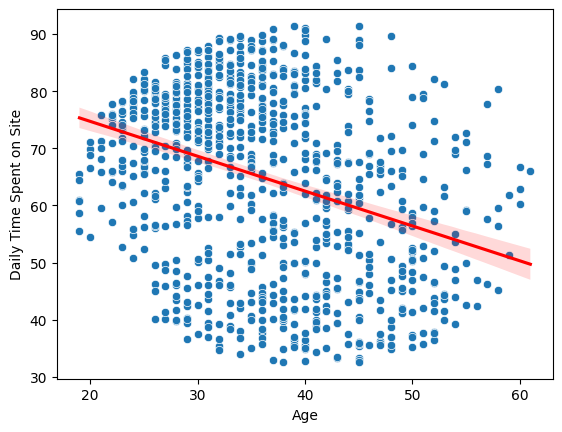

In [134]:
sns.scatterplot(x='Age', y='Daily Time Spent on Site', data=df)
sns.regplot(x='Age', y='Daily Time Spent on Site', data=df,
            scatter=False, color='red')

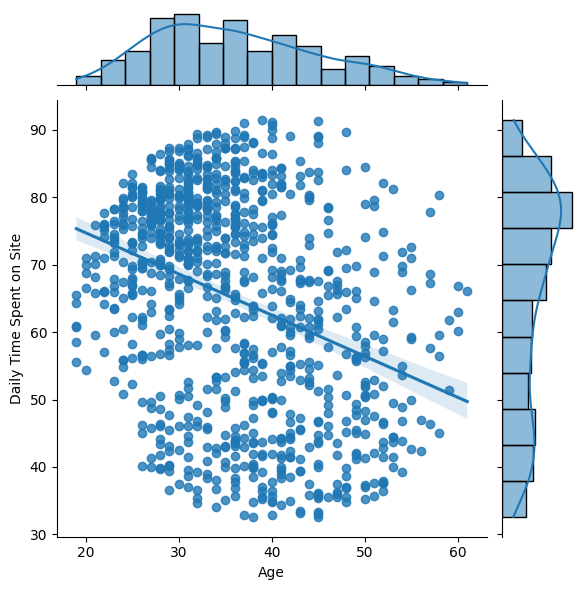

In [135]:
sns.jointplot(
    x='Age',
    y='Daily Time Spent on Site',
    data=df ,
    kind='reg'
)

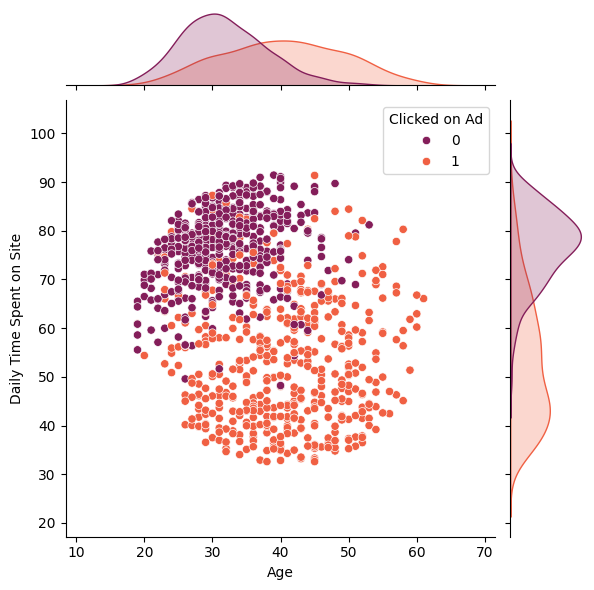

In [136]:
sns.jointplot(x='Age',y='Daily Time Spent on Site', data=df, hue="Clicked on Ad", palette='rocket')

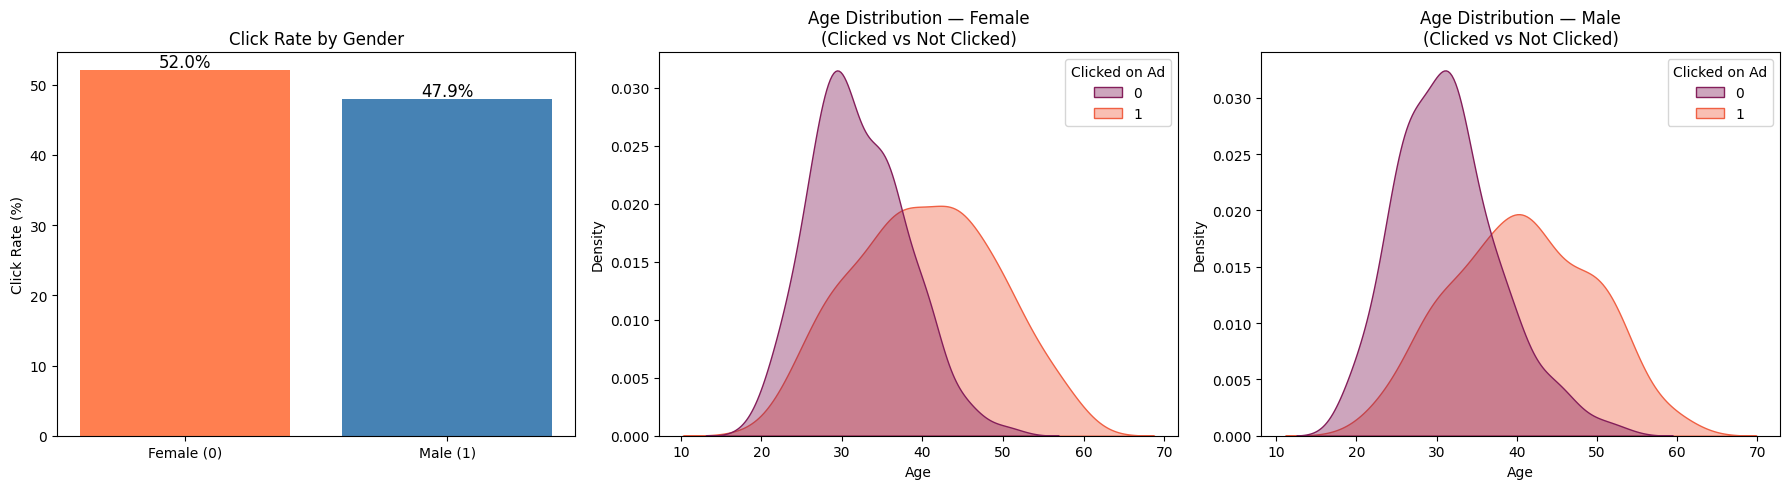


Click counts by gender:
Clicked on Ad    0    1
Male                   
0.0            237  257
1.0            239  220


C:\Users\hp5cd\AppData\Local\Temp\ipykernel_21948\1672608944.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Female', 'Male'])
C:\Users\hp5cd\AppData\Local\Temp\ipykernel_21948\1672608944.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Female', 'Male'])


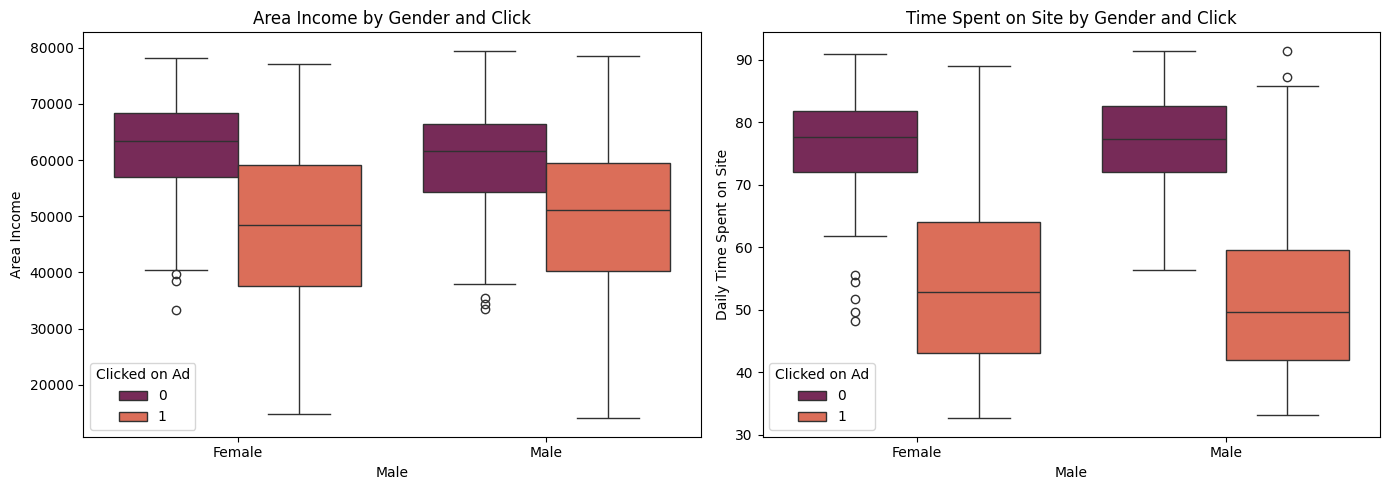

In [137]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Click rate by gender
gender_click = df.groupby('Male')['Clicked on Ad'].mean() * 100
axes[0].bar(['Female (0)', 'Male (1)'], gender_click.values, color=['coral', 'steelblue'])
axes[0].set_title('Click Rate by Gender')
axes[0].set_ylabel('Click Rate (%)')
for i, v in enumerate(gender_click.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=12)

# 2. Age distribution by gender (hue=click)
sns.kdeplot(data=df[df['Male'] == 0], x='Age', hue='Clicked on Ad',
            ax=axes[1], palette='rocket', fill=True, alpha=0.4)
axes[1].set_title('Age Distribution — Female\n(Clicked vs Not Clicked)')
axes[1].set_xlabel('Age')

sns.kdeplot(data=df[df['Male'] == 1], x='Age', hue='Clicked on Ad',
            ax=axes[2], palette='rocket', fill=True, alpha=0.4)
axes[2].set_title('Age Distribution — Male\n(Clicked vs Not Clicked)')
axes[2].set_xlabel('Age')

plt.tight_layout()
plt.show()

# 3. Count of clicks by gender
print("\nClick counts by gender:")
print(df.groupby(['Male', 'Clicked on Ad']).size().unstack())

# 4. Internet usage & time spent by gender and click
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='Male', y='Area Income', hue='Clicked on Ad',
            data=df, ax=axes[0], palette='rocket')
axes[0].set_title('Area Income by Gender and Click')
axes[0].set_xticklabels(['Female', 'Male'])

sns.boxplot(x='Male', y='Daily Time Spent on Site', hue='Clicked on Ad',
            data=df, ax=axes[1], palette='rocket')
axes[1].set_title('Time Spent on Site by Gender and Click')
axes[1].set_xticklabels(['Female', 'Male'])

plt.tight_layout()
plt.show()

<Axes: xlabel='Daily Time Spent on Site', ylabel='Area Income'>

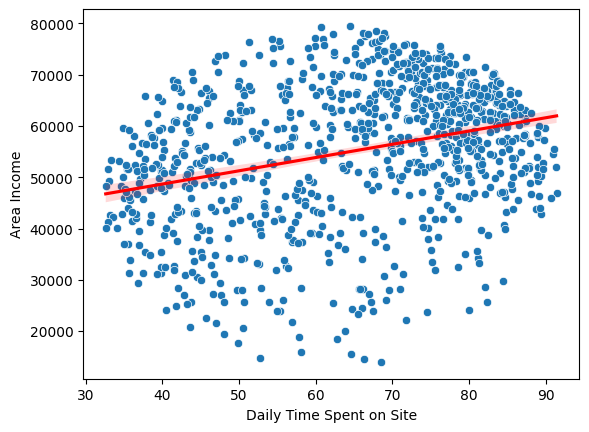

In [138]:
sns.scatterplot(x='Daily Time Spent on Site', y='Area Income', data=df)
sns.regplot(x='Daily Time Spent on Site', y='Area Income', data=df,
            scatter=False, color='red')

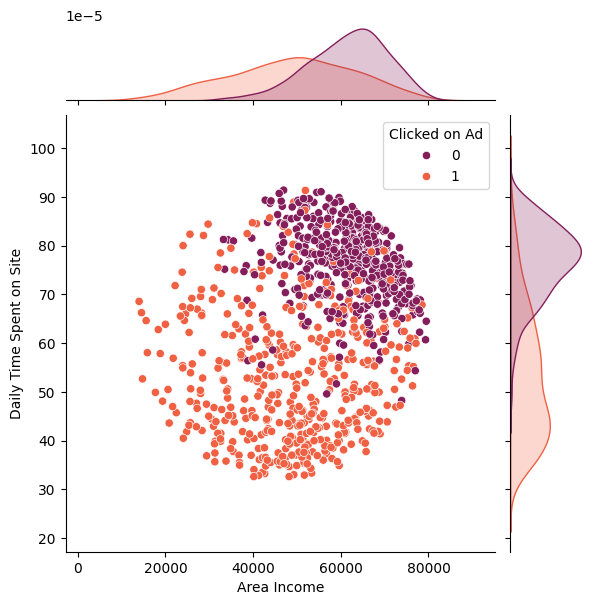

In [139]:
sns.jointplot(x='Area Income',y='Daily Time Spent on Site', data=df, hue="Clicked on Ad", palette='rocket')

<Axes: xlabel='Daily Internet Usage', ylabel='Age'>

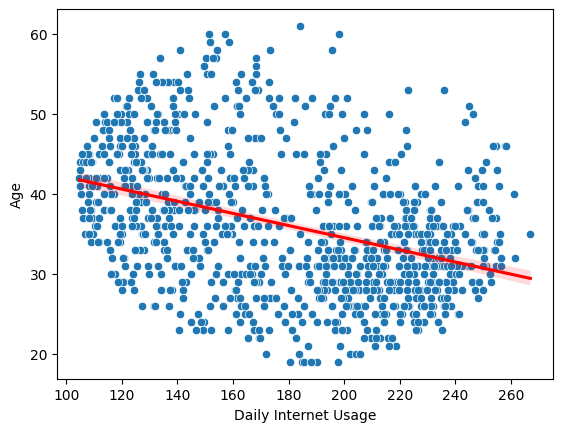

In [140]:
sns.scatterplot(x='Daily Internet Usage', y='Age', data=df)
sns.regplot(x='Daily Internet Usage', y='Age', data=df,
            scatter=False, color='red')

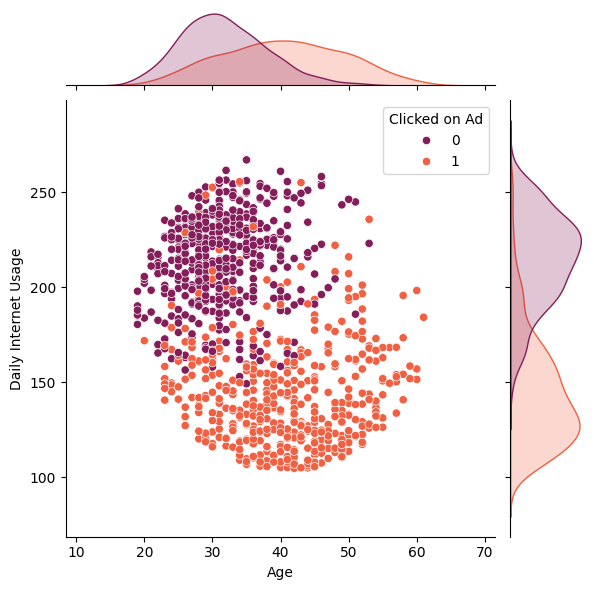

In [141]:
sns.jointplot(x='Age',y='Daily Internet Usage', data=df, hue="Clicked on Ad", palette='rocket')

<Axes: xlabel='Daily Time Spent on Site', ylabel='Daily Internet Usage'>

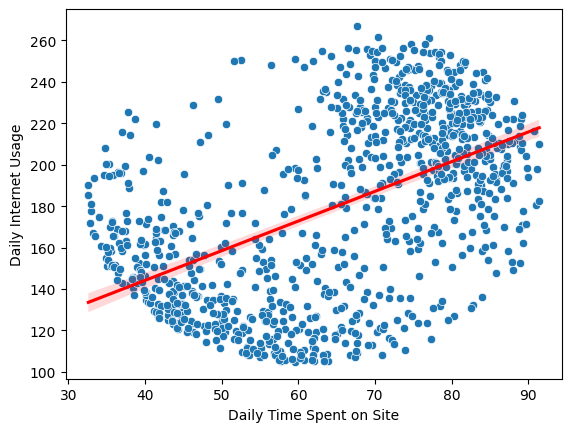

In [142]:
sns.scatterplot(x='Daily Time Spent on Site', y='Daily Internet Usage', data=df)
sns.regplot(x='Daily Time Spent on Site', y='Daily Internet Usage', data=df,
            scatter=False, color='red')

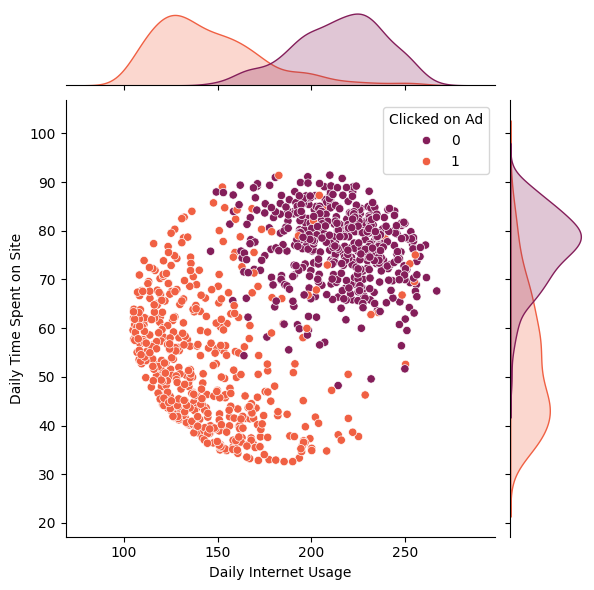

In [143]:
sns.jointplot(x='Daily Internet Usage',y='Daily Time Spent on Site', data=df, hue="Clicked on Ad", palette='rocket')


<Axes: >

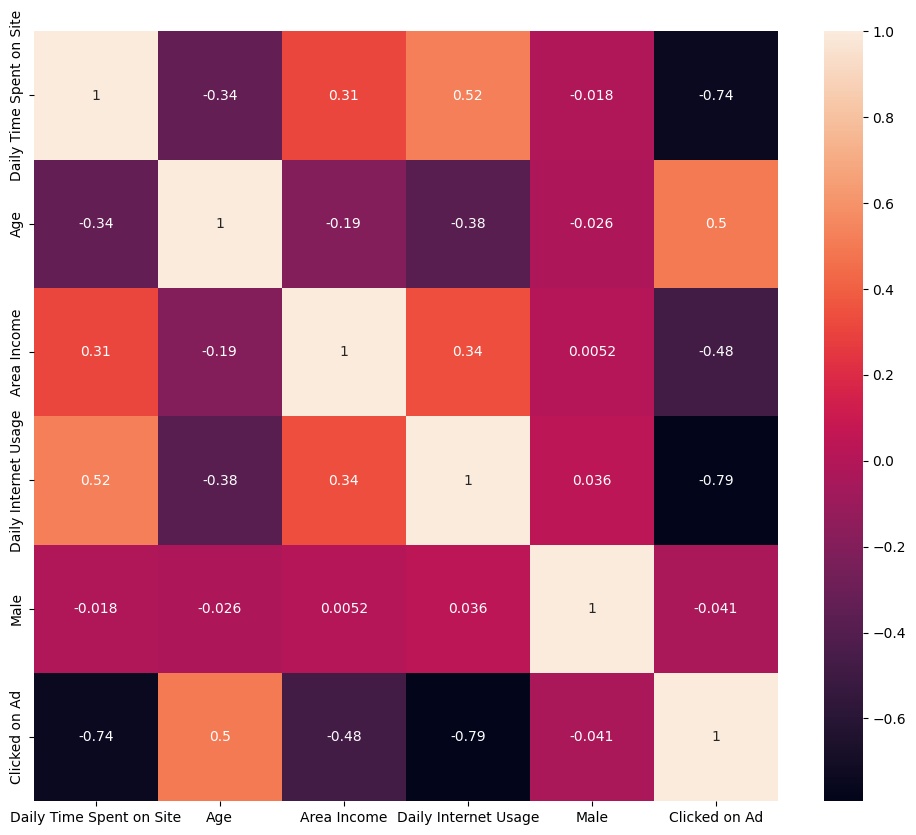

In [144]:
fig = plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only = True), annot=True)

In [145]:
df['Ad Topic Line'].describe(include=['O'])

count                                 953
unique                                953
top       Virtual 5thgeneration emulation
freq                                    1
Name: Ad Topic Line, dtype: object

In [146]:
df['City'].describe(include=['O'])

count              953
unique             926
top       Williamsport
freq                 3
Name: City, dtype: object

In [147]:
df['Country'].describe(include=['O'])

count                953
unique               235
top       Czech Republic
freq                   9
Name: Country, dtype: object

In [148]:
df = df[['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage', 'Male','Timestamp', 'Clicked on Ad']].copy()

In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 953 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  953 non-null    float64
 1   Age                       953 non-null    int64  
 2   Area Income               953 non-null    float64
 3   Daily Internet Usage      953 non-null    float64
 4   Male                      953 non-null    float64
 5   Timestamp                 953 non-null    object 
 6   Clicked on Ad             953 non-null    int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 59.6+ KB


In [150]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [151]:
df["Month"] = df['Timestamp'].dt.month

In [152]:
df['Day'] = df['Timestamp'].dt.day

In [153]:
df['Weekday'] = df['Timestamp'].dt.dayofweek

In [154]:
df['Hour'] = df['Timestamp'].dt.hour

In [155]:
df['DayOfWeek'] = df['Timestamp'].dt.day_name()


In [156]:
df = df.drop(['Timestamp'], axis=1)

In [157]:
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad,Month,Day,Weekday,Hour,DayOfWeek
0,68.95,35,61833.90,256.09,0.0,0,3,27,6,0,Sunday
1,80.23,31,68441.85,193.77,1.0,0,4,4,0,1,Monday
2,69.47,26,59785.94,236.50,0.0,0,3,13,6,20,Sunday
3,74.15,29,54806.18,245.89,1.0,0,1,10,6,2,Sunday
4,68.37,35,73889.99,225.58,0.0,0,6,3,4,3,Friday


In [158]:
df['Month'].unique()

array([3, 4, 1, 6, 5, 7, 2], dtype=int32)

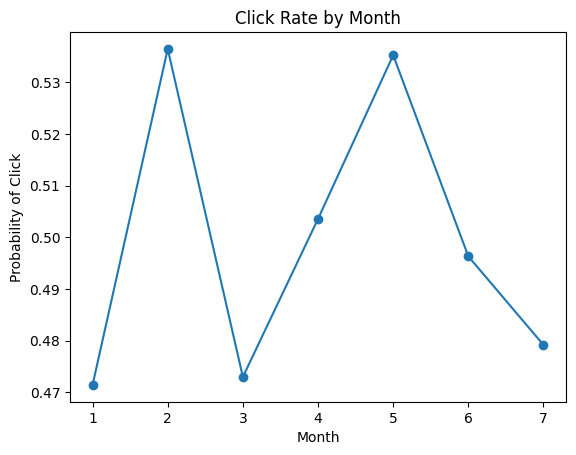

In [159]:
hour_click_rate = df.groupby('Month')['Clicked on Ad'].mean()

hour_click_rate.plot(kind='line', marker='o')
plt.title("Click Rate by Month")
plt.ylabel("Probability of Click")
plt.show()

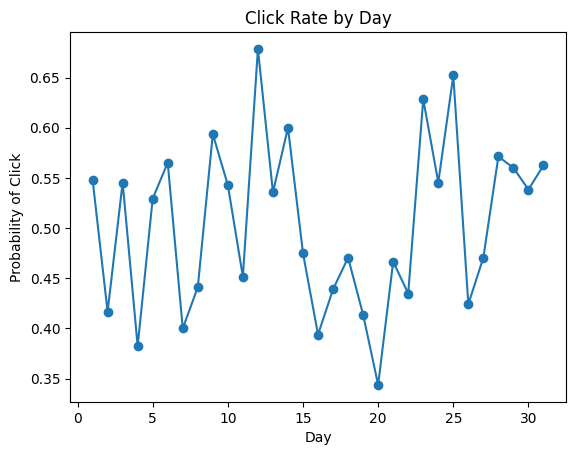

In [160]:
hour_click_rate = df.groupby('Day')['Clicked on Ad'].mean()

hour_click_rate.plot(kind='line', marker='o')
plt.title("Click Rate by Day")
plt.ylabel("Probability of Click")
plt.show()

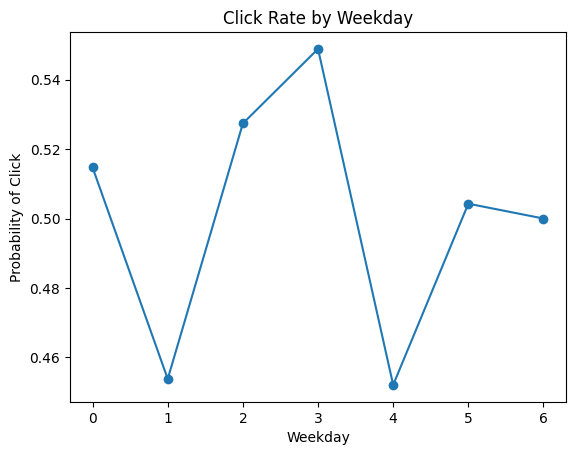

In [161]:
hour_click_rate = df.groupby('Weekday')['Clicked on Ad'].mean()

hour_click_rate.plot(kind='line', marker='o')
plt.title("Click Rate by Weekday")
plt.ylabel("Probability of Click")
plt.show()

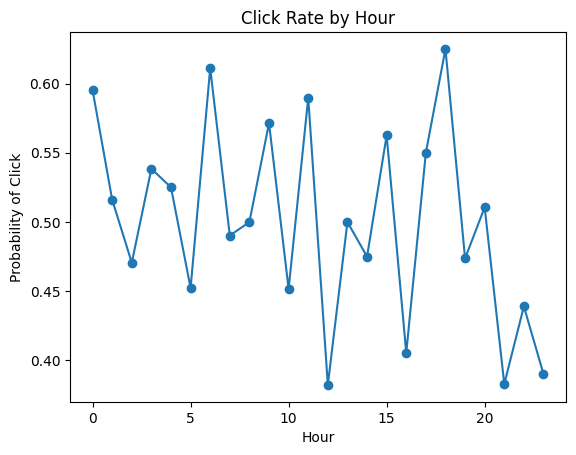

In [162]:
hour_click_rate = df.groupby('Hour')['Clicked on Ad'].mean()

hour_click_rate.plot(kind='line', marker='o')
plt.title("Click Rate by Hour")
plt.ylabel("Probability of Click")
plt.show()

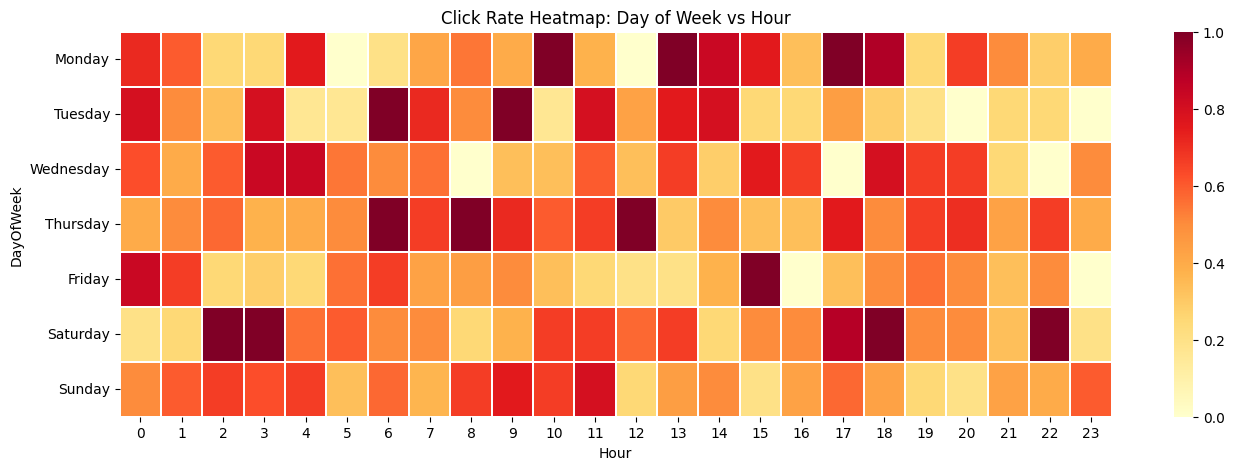

In [163]:


day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = df.pivot_table(values='Clicked on Ad', index='DayOfWeek', columns='Hour', aggfunc='mean')
pivot = pivot.reindex(day_order)

plt.figure(figsize=(16, 5))
sns.heatmap(pivot, cmap='YlOrRd', annot=False, linewidths=0.3)
plt.title('Click Rate Heatmap: Day of Week vs Hour')
plt.show()

<Axes: xlabel='Hour', ylabel='Daily Time Spent on Site'>

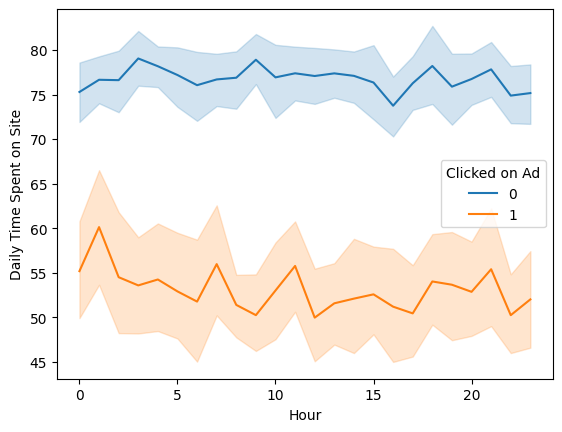

In [164]:
sns.lineplot(x='Hour', y='Daily Time Spent on Site', hue='Clicked on Ad', data=df)

<Axes: xlabel='Daily Time Spent on Site', ylabel='Count'>

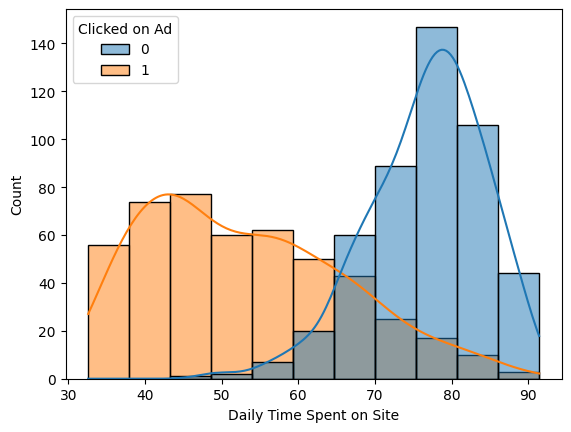

In [165]:
sns.histplot(data=df, x='Daily Time Spent on Site', hue='Clicked on Ad', kde=True)

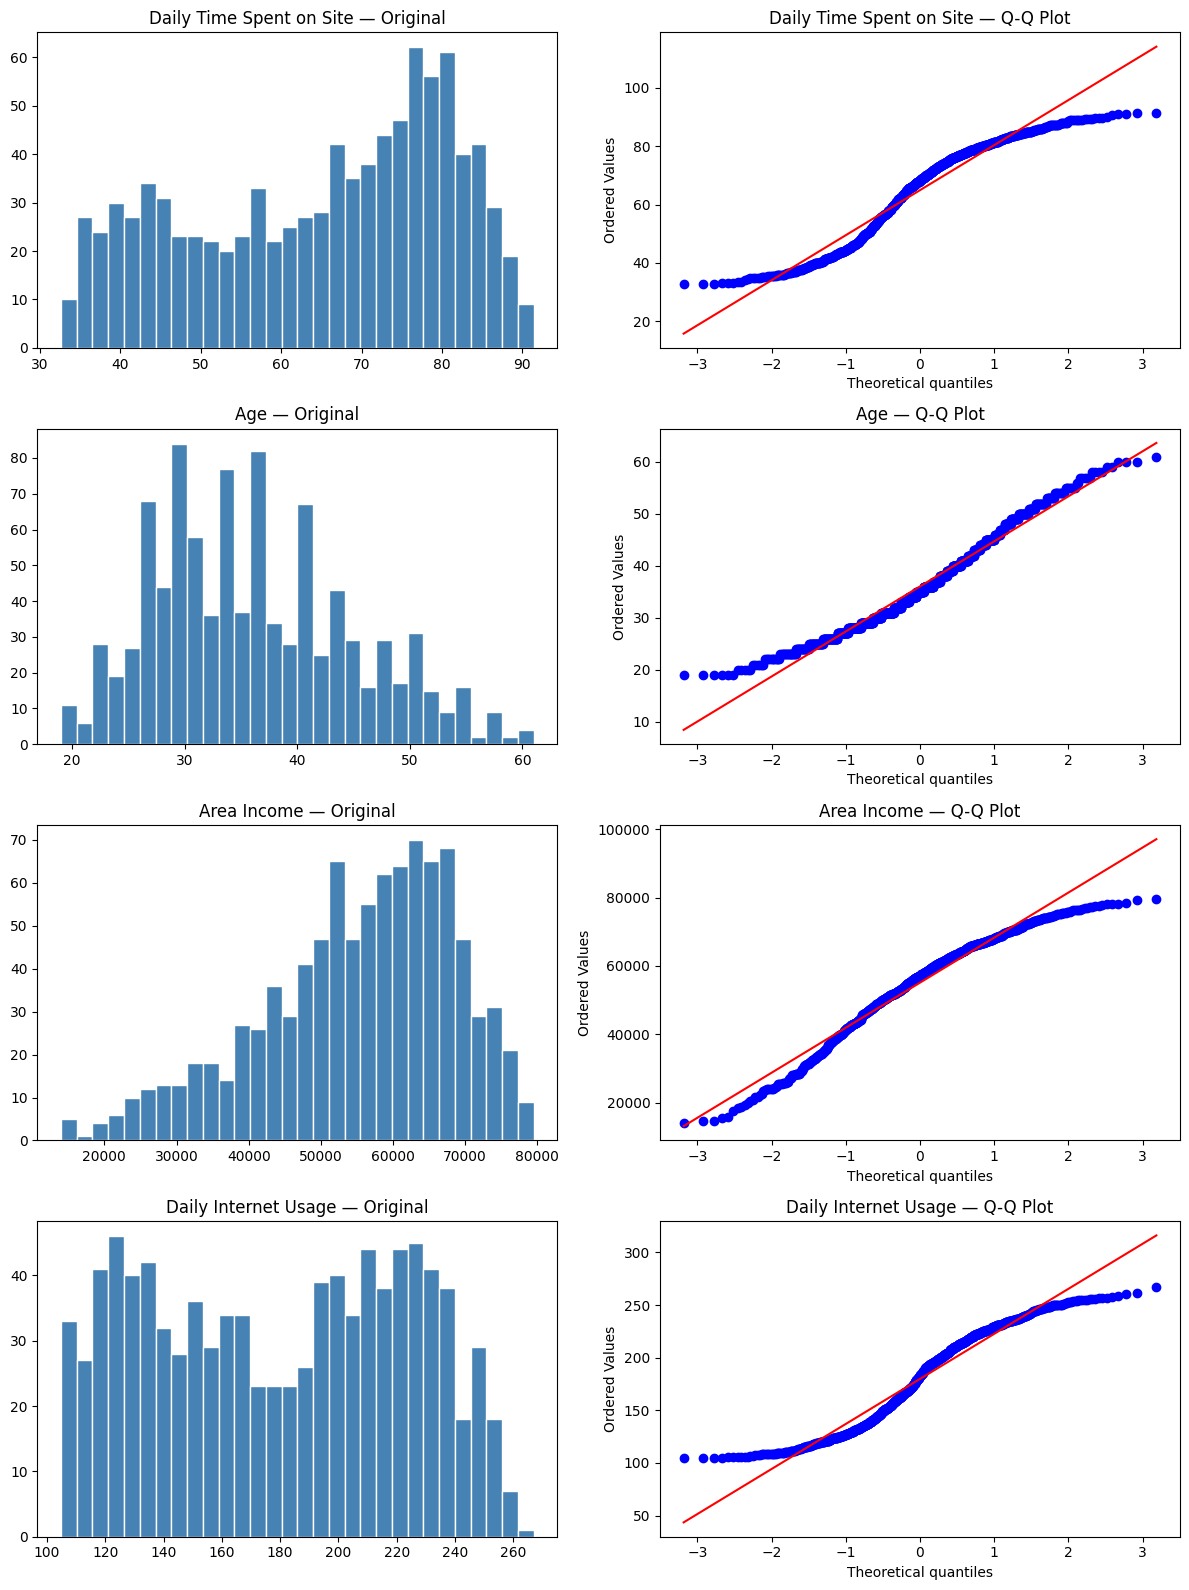

Skewness:
Daily Time Spent on Site   -0.376507
Age                         0.468162
Area Income                -0.654497
Daily Internet Usage       -0.035391
dtype: float64


In [166]:
import scipy.stats as stats

num_cols = ['Daily Time Spent on Site', 'Age', 'Area Income', 'Daily Internet Usage']

fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 16))

for i, col in enumerate(num_cols):
    # Original distribution
    axes[i, 0].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i, 0].set_title(f'{col} — Original')
    
    # Q-Q plot to check normality
    stats.probplot(df[col], plot=axes[i, 1])
    axes[i, 1].set_title(f'{col} — Q-Q Plot')

plt.tight_layout()
plt.show()

# Skewness values
print("Skewness:")
print(df[num_cols].skew())

In [167]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 953 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  953 non-null    float64
 1   Age                       953 non-null    int64  
 2   Area Income               953 non-null    float64
 3   Daily Internet Usage      953 non-null    float64
 4   Male                      953 non-null    float64
 5   Clicked on Ad             953 non-null    int64  
 6   Month                     953 non-null    int32  
 7   Day                       953 non-null    int32  
 8   Weekday                   953 non-null    int32  
 9   Hour                      953 non-null    int32  
 10  DayOfWeek                 953 non-null    object 
dtypes: float64(4), int32(4), int64(2), object(1)
memory usage: 74.5+ KB


In [169]:
x = df.drop(columns=['Clicked on Ad','DayOfWeek'], axis=1)

In [170]:
x.shape

(953, 9)

In [171]:
y = df['Clicked on Ad']

In [172]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [173]:
X_train.shape

(667, 9)

In [174]:
y_train.shape

(667,)

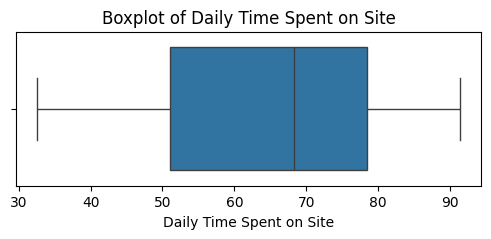

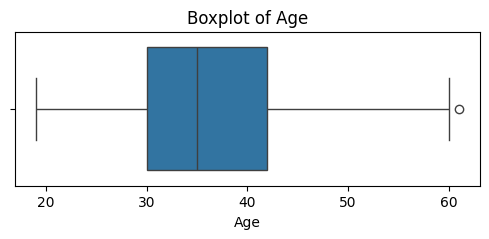

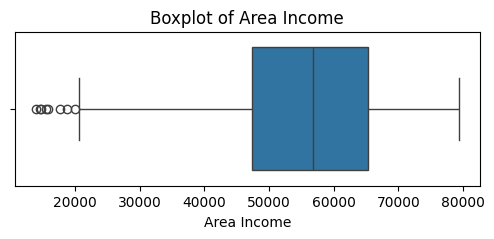

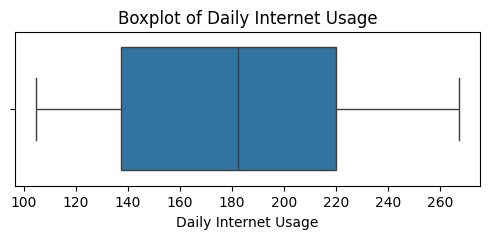

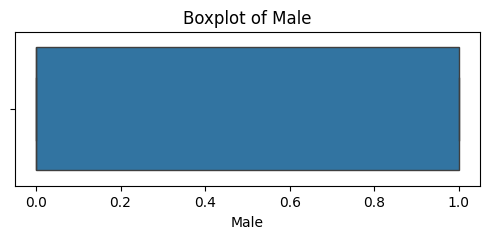

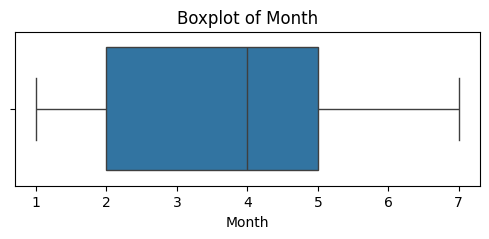

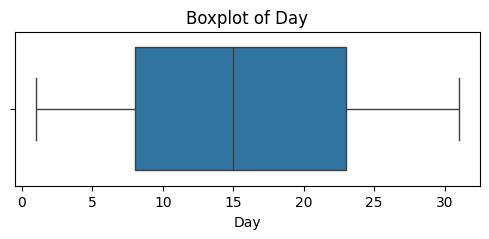

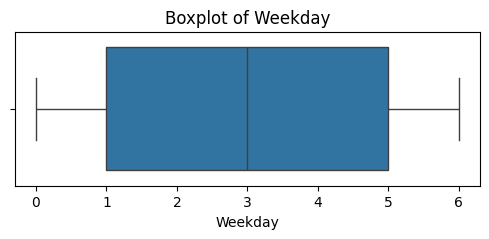

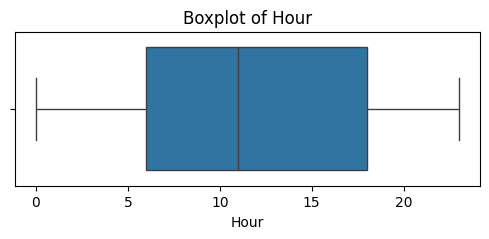

In [175]:
for col in X_train.columns:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=X_train[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [176]:
def remove_outliers_iqr(df, columns, multiplier=1.5):
    """
    Remove rows where any specified column has a value
    outside [Q1 - multiplier*IQR, Q3 + multiplier*IQR].
    
    multiplier=1.5 → standard outliers
    multiplier=3.0 → only extreme outliers
    """
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - multiplier * IQR
        upper = Q3 + multiplier * IQR
        before = len(df_clean)
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
        print(f"[IQR] {col}: removed {before - len(df_clean)} rows | "
              f"bounds [{lower:.2f}, {upper:.2f}]")
    return df_clean

In [177]:
X_train_clean = remove_outliers_iqr(X_train, columns=[ 'Area Income'], multiplier=1.5)
y_train = y_train.loc[X_train_clean.index]

[IQR] Area Income: removed 8 rows | bounds [20448.79, 92251.14]


In [178]:
scaler = StandardScaler()

In [179]:
X_train = scaler.fit_transform(X_train_clean)

In [180]:
X_test = scaler.transform(X_test)

In [181]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)


In [182]:
cnf_matrix = confusion_matrix(y_test,y_pred)
print(cnf_matrix)

[[141   7]
 [  2 136]]


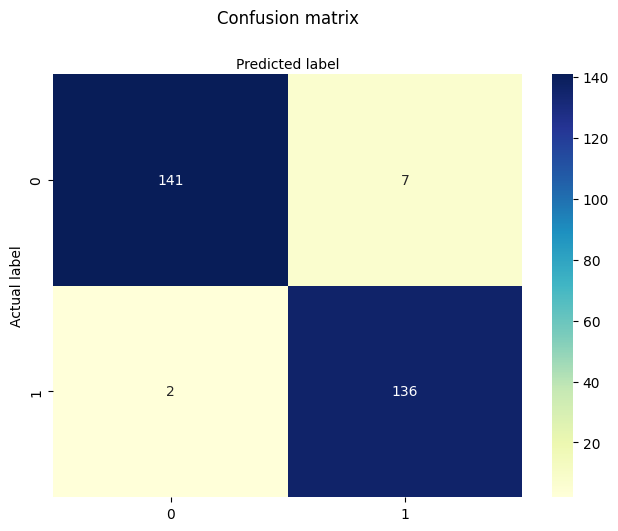

In [183]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

In [184]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97       148
           1       0.95      0.99      0.97       138

    accuracy                           0.97       286
   macro avg       0.97      0.97      0.97       286
weighted avg       0.97      0.97      0.97       286



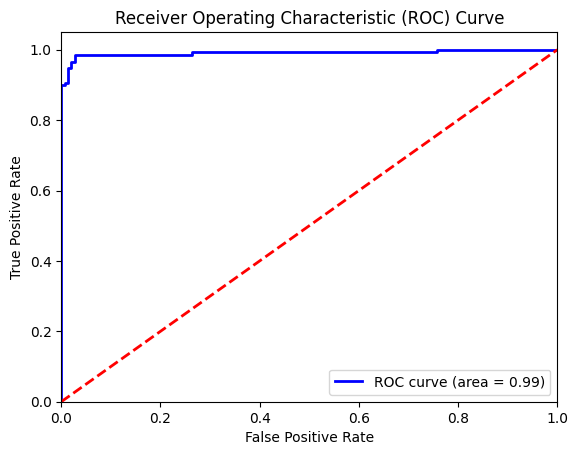

In [185]:
from sklearn.metrics import roc_curve, auc
y_prob = lr.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr) 
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')   
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [186]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [187]:
cnf_matrix = confusion_matrix(y_test,y_pred)
print(cnf_matrix)

[[136  12]
 [  5 133]]


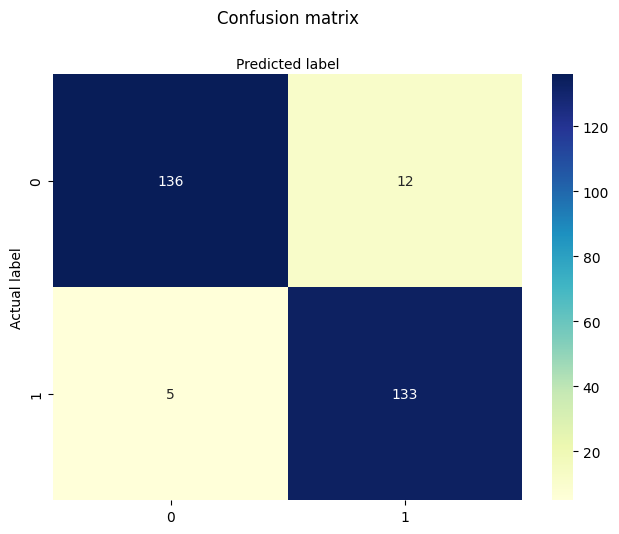

In [188]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

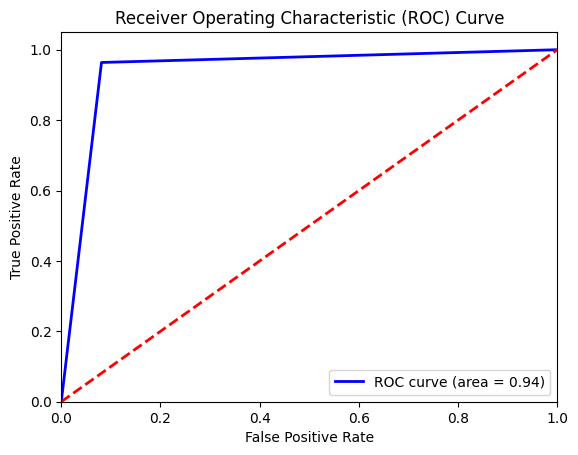

In [189]:
from sklearn.metrics import roc_curve, auc
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr) 
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')   
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


In [190]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.92      0.94       148
           1       0.92      0.96      0.94       138

    accuracy                           0.94       286
   macro avg       0.94      0.94      0.94       286
weighted avg       0.94      0.94      0.94       286



In [191]:
feature_names = ['Daily Time Spent on Site', 'Age', 'Area Income',
                 'Daily Internet Usage', 'Male','Month','Day','Weekday','Hour']

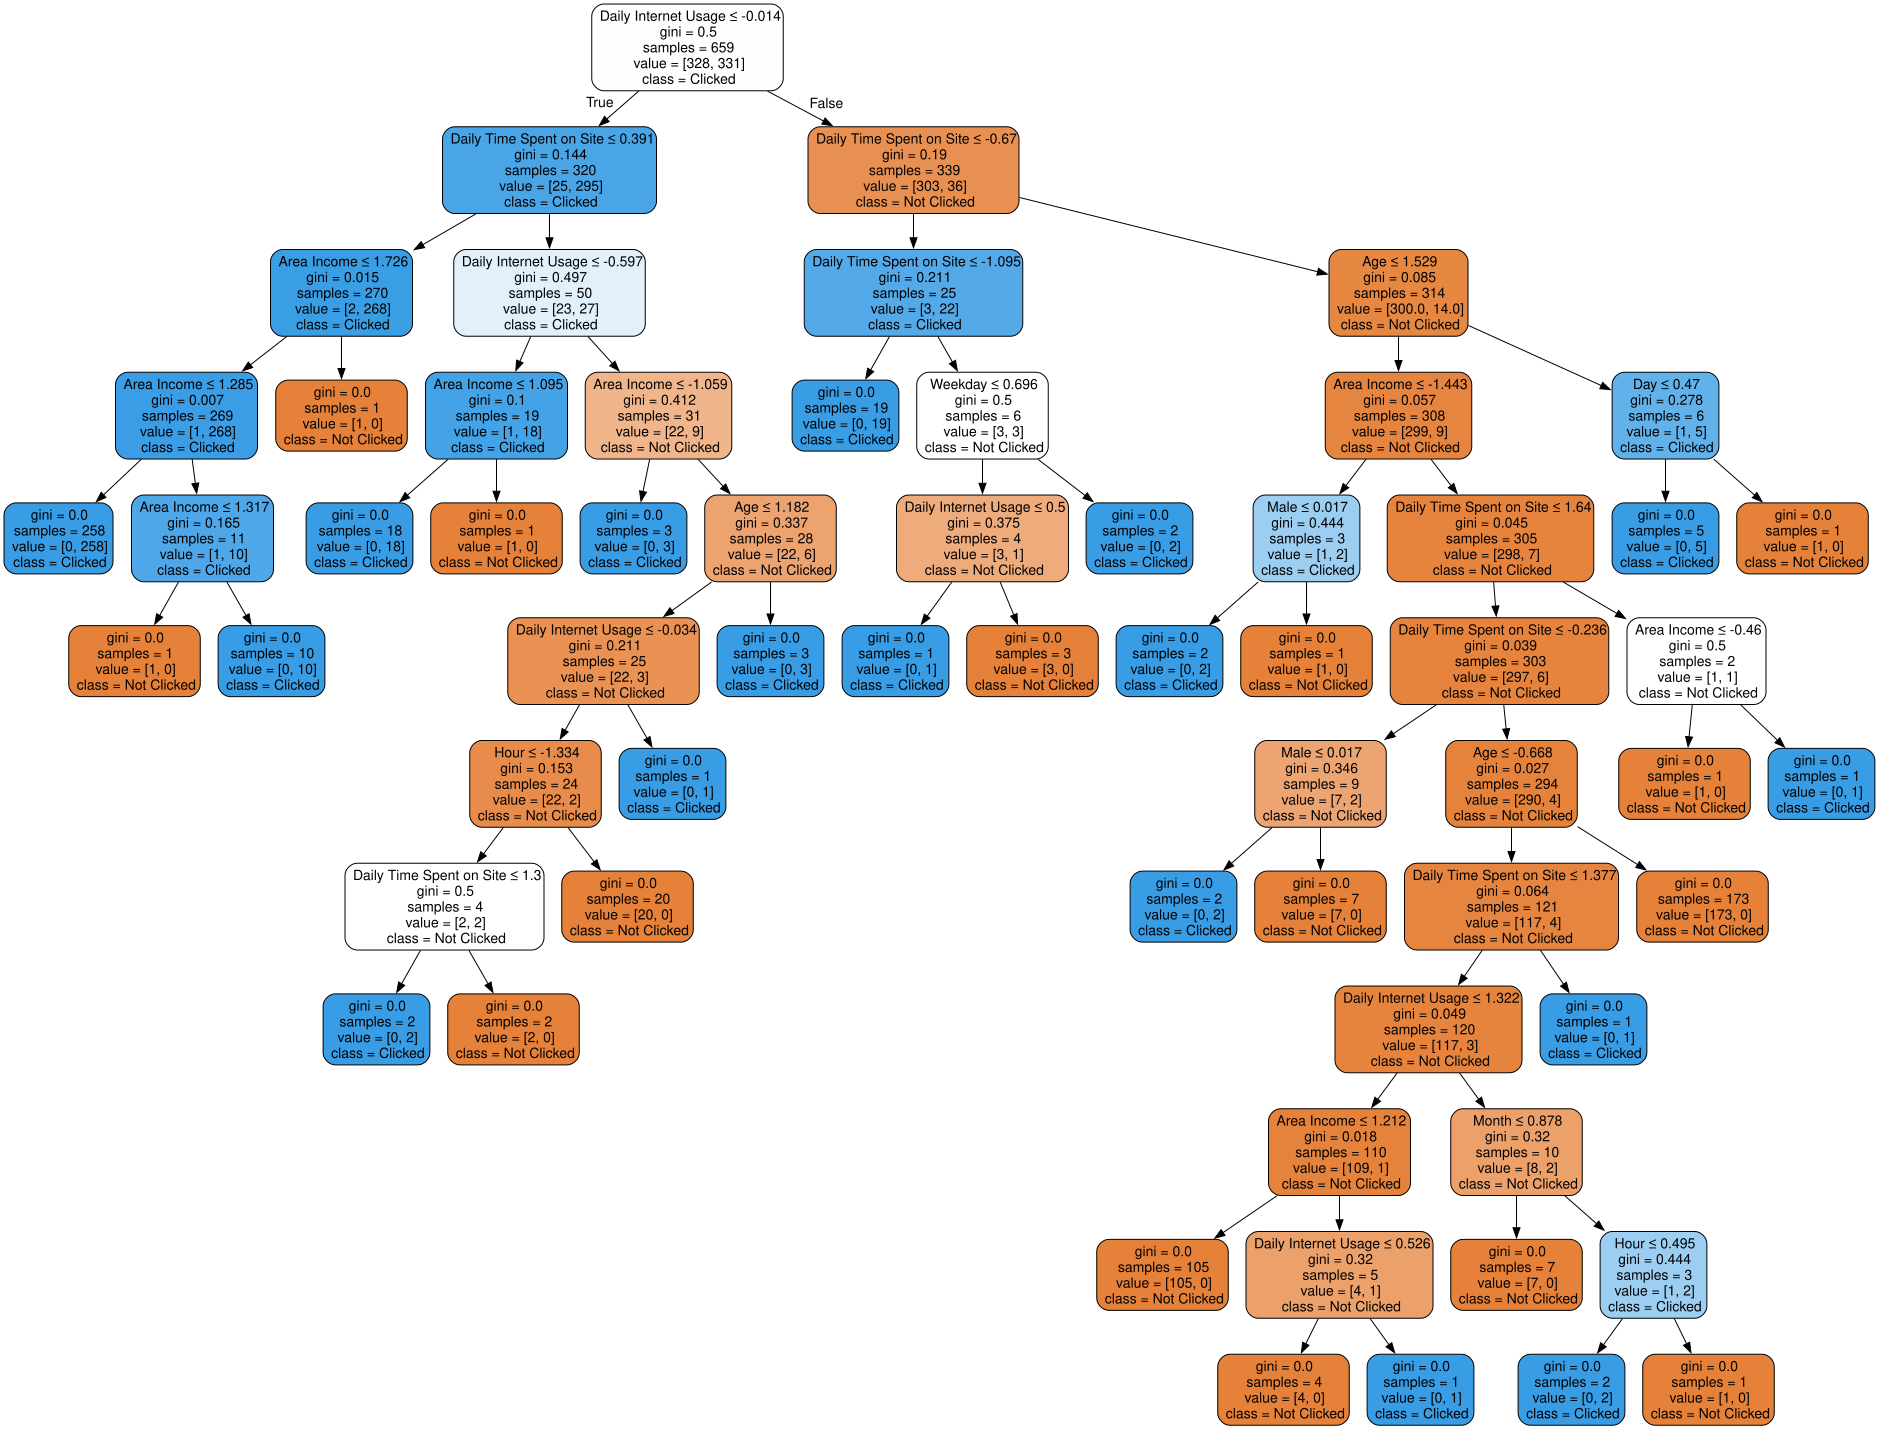

In [192]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    model,
    out_file=None,
    feature_names=feature_names,
    class_names=['Not Clicked', 'Clicked'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph

In [193]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#SVM model 
svm_model = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)


svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

In [194]:
cnf_matrix = confusion_matrix(y_test,y_pred_svm)
print(cnf_matrix)

[[143   5]
 [  4 134]]


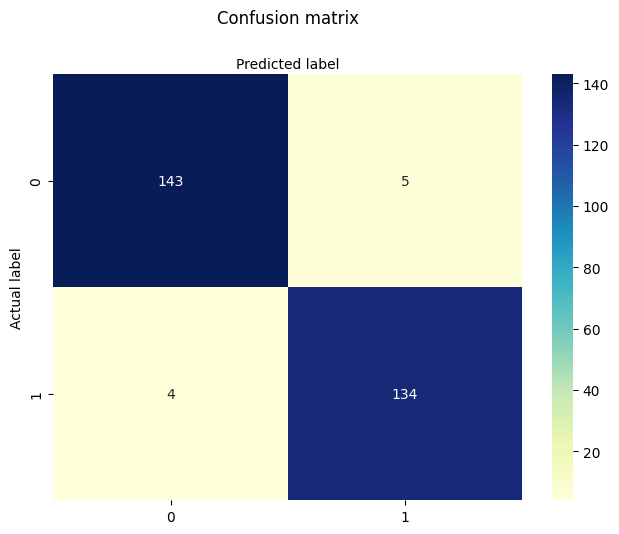

In [195]:
class_names=[0,1] 
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

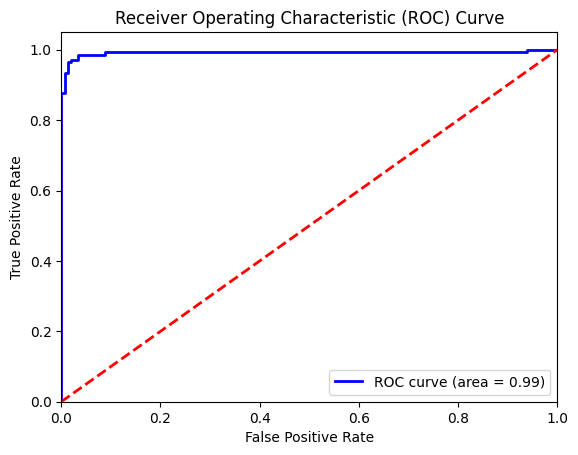

In [196]:
y_prob = svm_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr) 
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')   
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [197]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       148
           1       0.96      0.97      0.97       138

    accuracy                           0.97       286
   macro avg       0.97      0.97      0.97       286
weighted avg       0.97      0.97      0.97       286



In [198]:
from sklearn.tree import plot_tree
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [199]:
base = DecisionTreeClassifier(max_depth=1)

clf = AdaBoostClassifier(
    estimator=base,
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

In [200]:
clf.fit(X_train, y_train)
y_pred_ada = clf.predict(X_test)


In [201]:
classification_report(y_test, y_pred_ada)
print(classification_report(y_test, y_pred_ada))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96       148
           1       0.95      0.97      0.96       138

    accuracy                           0.96       286
   macro avg       0.96      0.96      0.96       286
weighted avg       0.96      0.96      0.96       286



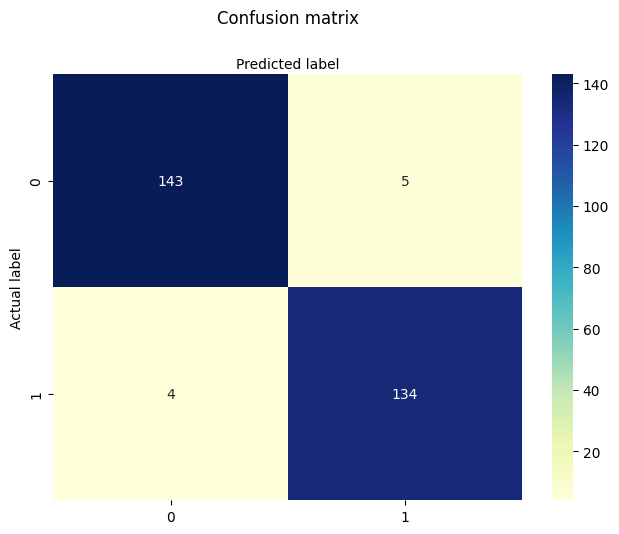

In [202]:
class_names=[0,1] 
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()

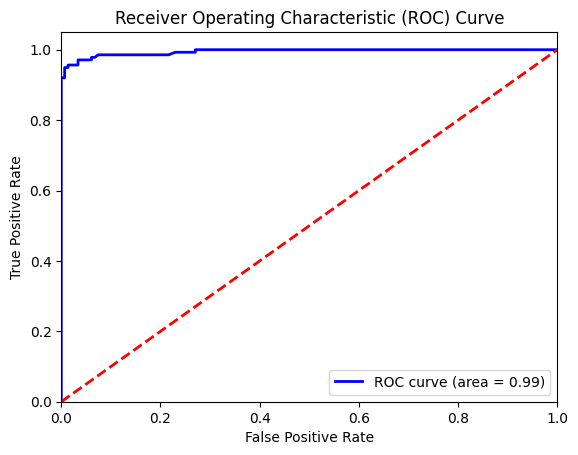

In [203]:
y_prob = clf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr) 
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')   
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [204]:
""" for i, tree in enumerate(clf.estimators_):
    dot_data = export_graphviz(
        tree,
        out_file=None,
        feature_names=feature_names,
        class_names=['Not Clicked', 'Clicked'],
        filled=True,
        rounded=True,
        special_characters=True
    )

    display(graphviz.Source(dot_data)) """

" for i, tree in enumerate(clf.estimators_):\n    dot_data = export_graphviz(\n        tree,\n        out_file=None,\n        feature_names=feature_names,\n        class_names=['Not Clicked', 'Clicked'],\n        filled=True,\n        rounded=True,\n        special_characters=True\n    )\n\n    display(graphviz.Source(dot_data)) "

In [205]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


xgb_classifier = xgb.XGBClassifier(
    n_estimators=100,      
    learning_rate=0.1,     
    max_depth=5,           
    random_state=42,      
    eval_metric='logloss' 
)

xgb_classifier.fit(X_train, y_train)


y_pred = xgb_classifier.predict(X_test)

cnf_matrix = confusion_matrix(y_test, y_pred)

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.97       148
           1       0.95      0.98      0.96       138

    accuracy                           0.97       286
   macro avg       0.96      0.97      0.97       286
weighted avg       0.97      0.97      0.97       286



In [206]:
print(confusion_matrix(y_test, y_pred))

[[141   7]
 [  3 135]]


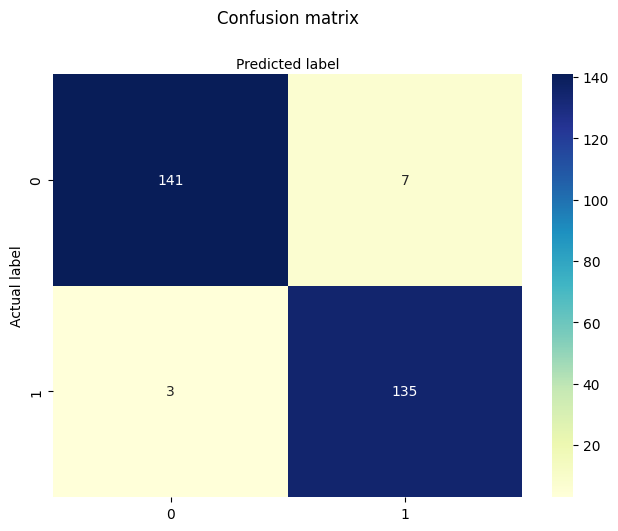

In [207]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()